# Deliverable D6, B3, & B4: Advanced Financial Analytics

This notebook covers:
1. **Value at Risk (VaR)** validation and correctness.
2. **Cohort Analysis** of investor transactions.
3. **Recommender Engine** logic demonstration.
4. **Monte Carlo Simulation (B3)** for NAV projection over 5 years.
5. **Markowitz Efficient Frontier Portfolio Optimization (B4)**.

In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_theme(style="whitegrid")
db_path = os.path.join("..", "data", "db", "bluestock_mf.db")
conn = sqlite3.connect(db_path)

## 1. Value at Risk (VaR) Validation
Value at Risk measures the maximum potential loss over a given time horizon at a specific confidence level. Here we compute:
- Historical VaR (95% and 99%)
- Parametric (Variance-Covariance) VaR (95% and 99%)
We use the daily returns of **SBI Bluechip Fund (amfi_code: 119551)**.

In [2]:
# Fetch daily returns for SBI Bluechip Fund
df_sbi = pd.read_sql_query("""
    SELECT date, nav FROM fact_nav 
    WHERE amfi_code = 119551 
    ORDER BY date
""", conn)
df_sbi['date'] = pd.to_datetime(df_sbi['date'])
df_sbi['returns'] = df_sbi['nav'].pct_change().dropna()
returns = df_sbi['returns'].dropna()

# 1. Historical VaR
var_hist_95 = np.percentile(returns, 5)
var_hist_99 = np.percentile(returns, 1)

# 2. Parametric VaR
mu = returns.mean()
sigma = returns.std()
var_param_95 = norm.ppf(0.05, mu, sigma)
var_param_99 = norm.ppf(0.01, mu, sigma)

print(f"Daily Returns - Mean: {mu:.6f}, StdDev: {sigma:.6f}")
print("--- 95% Confidence Level ---")
print(f"Historical VaR (95%): {var_hist_95 * 100:.4f}% (Daily return threshold)")
print(f"Parametric VaR (95%): {var_param_95 * 100:.4f}%")
print("--- 99% Confidence Level ---")
print(f"Historical VaR (99%): {var_hist_99 * 100:.4f}%")
print(f"Parametric VaR (99%): {var_param_99 * 100:.4f}%")

Daily Returns - Mean: 0.000656, StdDev: 0.007330
--- 95% Confidence Level ---
Historical VaR (95%): -1.1827% (Daily return threshold)
Parametric VaR (95%): -1.1402%
--- 99% Confidence Level ---
Historical VaR (99%): -1.7316%
Parametric VaR (99%): -1.6397%


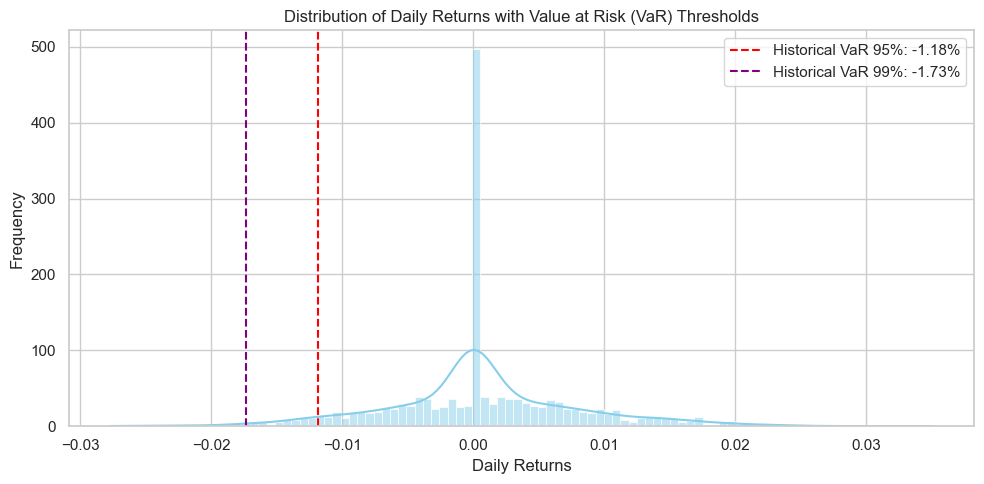

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(returns, bins=100, kde=True, color="skyblue")
plt.axvline(var_hist_95, color="red", linestyle="--", label=f"Historical VaR 95%: {var_hist_95*100:.2f}%")
plt.axvline(var_hist_99, color="purple", linestyle="--", label=f"Historical VaR 99%: {var_hist_99*100:.2f}%")
plt.title("Distribution of Daily Returns with Value at Risk (VaR) Thresholds")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Cohort Analysis of Investor Transaction Behavior
Cohort analysis lets us track active participation rates and transaction behavior.
We segment investors into cohorts based on their **first transaction month** and analyze their transaction retention over subsequent months.

In [4]:
df_tx = pd.read_sql_query("SELECT investor_id, transaction_date, amount_inr FROM fact_transactions", conn)
df_tx.rename(columns={'transaction_date': 'date'}, inplace=True)
df_tx['date'] = pd.to_datetime(df_tx['date'])
df_tx['tx_month'] = df_tx['date'].dt.to_period('M')

# Find first transaction month for each investor
df_tx['cohort_month'] = df_tx.groupby('investor_id')['date'].transform('min').dt.to_period('M')

# Calculate cohort index (periods active since first transaction)
df_tx['cohort_index'] = (df_tx['tx_month'].astype(int) - df_tx['cohort_month'].astype(int))

# Group by cohort month and cohort index, count unique investors
cohort_data = df_tx.groupby(['cohort_month', 'cohort_index'])['investor_id'].nunique().reset_index()

# Pivot to create the retention matrix
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='investor_id')

# Convert to percentages (retention rate)
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

print("Cohort Sizes:")
print(cohort_sizes.head(10))

Cohort Sizes:
cohort_month
2024-01    1577.0
2024-02     990.0
2024-03     669.0
2024-04     441.0
2024-05     294.0
2024-06     236.0
2024-07     175.0
2024-08     135.0
2024-09     100.0
2024-10      75.0
Freq: M, Name: 0, dtype: float64


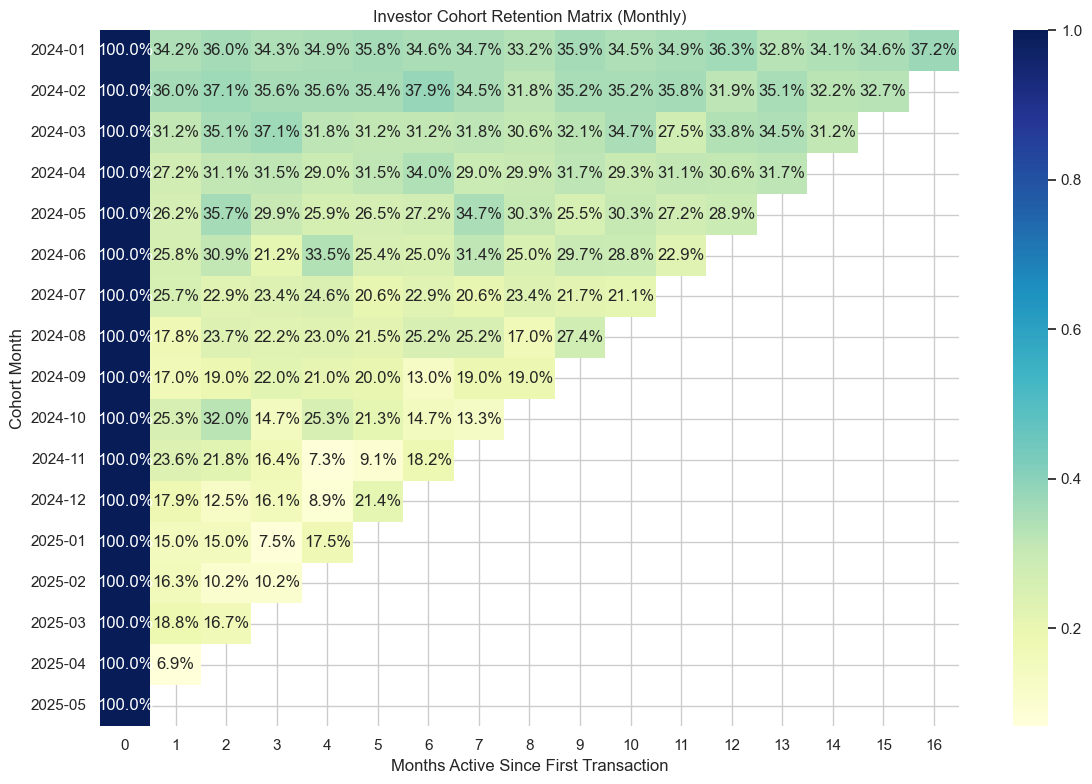

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt=".1%", cmap="YlGnBu", mask=retention_matrix.isnull())
plt.title("Investor Cohort Retention Matrix (Monthly)")
plt.xlabel("Months Active Since First Transaction")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

## 3. Recommender Engine Logic Demo
We demonstrate the demographics-based mutual fund recommendation engine.
The recommender matches investor ages and profiles with targeted mutual funds and filters out funds already owned by the investor.

In [6]:
# Add scripts folder to path so we can import the recommender
import sys
sys.path.append(os.path.join("..", "scripts"))
from recommender import MutualFundRecommender

recommender = MutualFundRecommender(db_path)

# Retrieve a few representative investor IDs from our transactions table
investors = pd.read_sql_query("""
    SELECT DISTINCT investor_id, age_group 
    FROM fact_transactions 
    GROUP BY age_group 
    LIMIT 3
""", conn)

for idx, inv_row in investors.iterrows():
    inv_id = inv_row['investor_id']
    age_grp = inv_row['age_group']
    print(f"\n==================================================")
    print(f"Investor ID: {inv_id} | Age Group: {age_grp}")
    print(f"==================================================")
    
    # Show their existing holdings
    holdings = pd.read_sql_query("""
        SELECT DISTINCT f.scheme_name, f.category, f.risk_category
        FROM fact_transactions t
        JOIN dim_fund f ON t.amfi_code = f.amfi_code
        WHERE t.investor_id = ?
    """, conn, params=(inv_id,))
    print("Current Holdings:")
    print(holdings.to_string(index=False))
    
    # Recommendations
    recs = recommender.recommend_for_investor(inv_id)
    print("\nRecommendations Inferred by Profile:")
    if isinstance(recs, pd.DataFrame):
        print(recs[['scheme_name', 'category', 'risk_category', 'morningstar_rating', 'sharpe_ratio']].to_string(index=False))
    else:
        print(recs)


Investor ID: INV002952 | Age Group: 18-25
Current Holdings:
                                   scheme_name category risk_category
 Mirae Asset Large Cap Fund - Regular - Growth   Equity      Moderate
      ICICI Pru Midcap Fund - Regular - Growth   Equity          High
        ABSL Small Cap Fund - Regular - Growth   Equity     Very High
  HDFC Short Term Debt Fund - Regular - Growth     Debt           Low
Nippon India Small Cap Fund - Regular - Growth   Equity     Very High

Recommendations Inferred by Profile:
                                       scheme_name category risk_category  morningstar_rating  sharpe_ratio
        SBI Small Cap Fund - Regular Plan - Growth   Equity     Very High                   5          0.94
HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity          High                   5          0.87
               UTI Mid Cap Fund - Regular - Growth   Equity          High                   5          0.82

Investor ID: INV004691 | Age Group: 26-35
Curren

## 4. Monte Carlo NAV Growth Simulation (B3)
We simulate the 5-year daily NAV progression of **SBI Bluechip Fund (119551)** using a Geometric Brownian Motion model.
Daily return distribution parameters: $\mu$ (drift) and $\sigma$ (volatility).
We run 1,000 simulations over 5 years (1,260 trading days) and plot the expected projection and uncertainty bands.

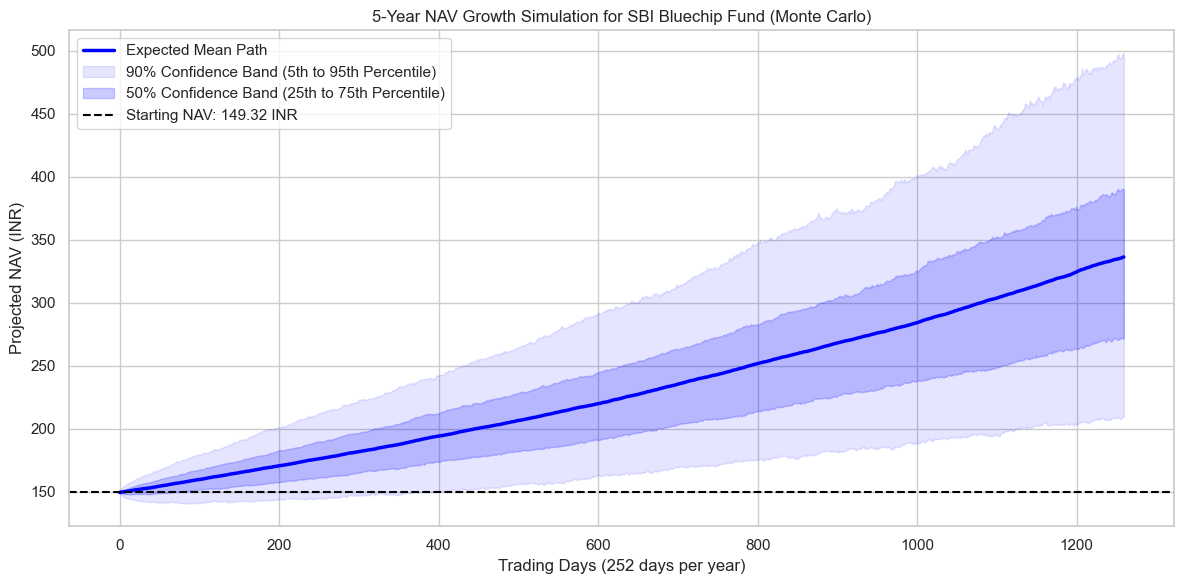

Starting NAV: 149.32 INR
Projected Expected NAV (5 Years): 336.25 INR (Expected Return: 125.18%)
95th Percentile (Optimistic Case): 498.14 INR
5th Percentile (Pessimistic Case): 209.23 INR


In [7]:
np.random.seed(42)

# Retrieve daily returns parameters
last_nav = df_sbi['nav'].iloc[-1]
returns = df_sbi['nav'].pct_change().dropna()
mu = returns.mean()
sigma = returns.std()

# Parameters for projection
n_days = 252 * 5
n_simulations = 1000  # 1000 runs for smooth bands

# Matrix to hold simulated NAVs
sim_nav = np.zeros((n_days, n_simulations))
sim_nav[0, :] = last_nav

# Simulation using Euler-Maruyama discretization of Geometric Brownian Motion
for t in range(1, n_days):
    shocks = np.random.normal(mu, sigma, n_simulations)
    sim_nav[t, :] = sim_nav[t-1, :] * (1 + shocks)

# Calculate expected path and quantiles
mean_path = np.mean(sim_nav, axis=1)
pct_95 = np.percentile(sim_nav, 95, axis=1)
pct_75 = np.percentile(sim_nav, 75, axis=1)
pct_25 = np.percentile(sim_nav, 25, axis=1)
pct_5 = np.percentile(sim_nav, 5, axis=1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(mean_path, color="blue", linewidth=2.5, label="Expected Mean Path")
plt.fill_between(range(n_days), pct_5, pct_95, color="blue", alpha=0.1, label="90% Confidence Band (5th to 95th Percentile)")
plt.fill_between(range(n_days), pct_25, pct_75, color="blue", alpha=0.2, label="50% Confidence Band (25th to 75th Percentile)")
plt.axhline(last_nav, color="black", linestyle="--", label=f"Starting NAV: {last_nav:.2f} INR")

plt.title("5-Year NAV Growth Simulation for SBI Bluechip Fund (Monte Carlo)")
plt.xlabel("Trading Days (252 days per year)")
plt.ylabel("Projected NAV (INR)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"Starting NAV: {last_nav:.2f} INR")
print(f"Projected Expected NAV (5 Years): {mean_path[-1]:.2f} INR (Expected Return: {((mean_path[-1]/last_nav)-1)*100:.2f}%)")
print(f"95th Percentile (Optimistic Case): {pct_95[-1]:.2f} INR")
print(f"5th Percentile (Pessimistic Case): {pct_5[-1]:.2f} INR")

## 5. Markowitz Efficient Frontier Optimization (B4)
We optimize a portfolio containing 5 key Bluechip funds:
1. SBI Bluechip (119551)
2. ICICI Bluechip (120503)
3. Nippon Large Cap (118632)
4. Axis Bluechip (119092)
5. Kotak Bluechip (120841)

We fetch their historical daily NAVs, calculate daily return vectors, compute mean returns, and standard deviation covariance matrix.
We simulate 10,000 random portfolios, plot the Markowitz Efficient Frontier, and identify the Minimum Variance Portfolio (MVP) and the Optimal Sharpe Ratio Portfolio.

In [8]:
# List of 5 selected funds
amfi_codes = [119551, 120503, 118632, 119092, 120841]

# Query their NAV histories
nav_query = """
    SELECT date, amfi_code, nav 
    FROM fact_nav 
    WHERE amfi_code IN (119551, 120503, 118632, 119092, 120841)
    ORDER BY date
"""
df_frontier = pd.read_sql_query(nav_query, conn)
df_frontier['date'] = pd.to_datetime(df_frontier['date'])

# Pivot to wide format: Date on index, amfi_code on columns
df_frontier_pivot = df_frontier.pivot(index='date', columns='amfi_code', values='nav')

# Calculate daily pct change returns
returns_df = df_frontier_pivot.pct_change().dropna()

# Map amfi_codes to fund house names for readable legends
names_map = {
    119551: 'SBI Bluechip',
    120503: 'ICICI Bluechip',
    118632: 'Nippon Large Cap',
    119092: 'Axis Bluechip',
    120841: 'Kotak Bluechip'
}
returns_df.rename(columns=names_map, inplace=True)

# Calculate annual returns and covariance matrix (assuming 252 trading days)
mean_daily = returns_df.mean()
ann_returns = mean_daily * 252
cov_matrix = returns_df.cov() * 252

print("Annualized Expected Returns:")
print(ann_returns)
print("\nAnnualized Covariance Matrix:")
print(cov_matrix)

Annualized Expected Returns:
amfi_code
Nippon Large Cap    0.155896
Axis Bluechip       0.049545
SBI Bluechip        0.165188
ICICI Bluechip      0.125692
Kotak Bluechip      0.094056
dtype: float64

Annualized Covariance Matrix:
amfi_code         Nippon Large Cap  Axis Bluechip  SBI Bluechip  \
amfi_code                                                         
Nippon Large Cap          0.014347       0.000465     -0.000434   
Axis Bluechip             0.000465       0.013916     -0.000534   
SBI Bluechip             -0.000434      -0.000534      0.013541   
ICICI Bluechip            0.000057       0.000553     -0.000167   
Kotak Bluechip           -0.000617       0.000758     -0.000402   

amfi_code         ICICI Bluechip  Kotak Bluechip  
amfi_code                                         
Nippon Large Cap        0.000057       -0.000617  
Axis Bluechip           0.000553        0.000758  
SBI Bluechip           -0.000167       -0.000402  
ICICI Bluechip          0.013805       -0.000

In [9]:
np.random.seed(42)
num_portfolios = 10000
num_assets = len(amfi_codes)

results = np.zeros((3, num_portfolios))
weights_record = []

rf_rate = 0.06  # Annual Risk-Free Rate (6%)

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)  # sum of weights must equal 1.0
    weights_record.append(weights)
    
    # Portfolio expected return
    portfolio_return = np.dot(weights, ann_returns)
    # Portfolio volatility
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    results[0, i] = portfolio_volatility
    results[1, i] = portfolio_return
    results[2, i] = (portfolio_return - rf_rate) / portfolio_volatility  # Sharpe Ratio

# Convert results matrix and weights to a DataFrame
columns = ['volatility', 'return', 'sharpe']
df_portfolios = pd.DataFrame(results.T, columns=columns)

# Find key portfolios
max_sharpe_idx = df_portfolios['sharpe'].idxmax()
min_vol_idx = df_portfolios['volatility'].idxmin()

optimal_weights = weights_record[max_sharpe_idx]
min_vol_weights = weights_record[min_vol_idx]

print("==================================================")
print("OPTIMAL SHARPE RATIO PORTFOLIO (TANGENCY)")
print("==================================================")
print(f"Expected Return: {df_portfolios.loc[max_sharpe_idx, 'return'] * 100:.2f}%")
print(f"Volatility: {df_portfolios.loc[max_sharpe_idx, 'volatility'] * 100:.2f}%")
print(f"Sharpe Ratio: {df_portfolios.loc[max_sharpe_idx, 'sharpe']:.4f}")
print("Asset Allocation Weights:")
for asset, weight in zip(returns_df.columns, optimal_weights):
    print(f" - {asset}: {weight * 100:.2f}%")

print("\n==================================================")
print("MINIMUM VARIANCE PORTFOLIO")
print("==================================================")
print(f"Expected Return: {df_portfolios.loc[min_vol_idx, 'return'] * 100:.2f}%")
print(f"Volatility: {df_portfolios.loc[min_vol_idx, 'volatility'] * 100:.2f}%")
print(f"Sharpe Ratio: {df_portfolios.loc[min_vol_idx, 'sharpe']:.4f}")
print("Asset Allocation Weights:")
for asset, weight in zip(returns_df.columns, min_vol_weights):
    print(f" - {asset}: {weight * 100:.2f}%")

OPTIMAL SHARPE RATIO PORTFOLIO (TANGENCY)
Expected Return: 14.45%
Volatility: 6.04%
Sharpe Ratio: 1.3998
Asset Allocation Weights:
 - Nippon Large Cap: 30.92%
 - Axis Bluechip: 0.36%
 - SBI Bluechip: 34.14%
 - ICICI Bluechip: 22.86%
 - Kotak Bluechip: 11.72%

MINIMUM VARIANCE PORTFOLIO
Expected Return: 11.99%
Volatility: 5.17%
Sharpe Ratio: 1.1584
Asset Allocation Weights:
 - Nippon Large Cap: 19.06%
 - Axis Bluechip: 18.39%
 - SBI Bluechip: 23.10%
 - ICICI Bluechip: 18.49%
 - Kotak Bluechip: 20.97%


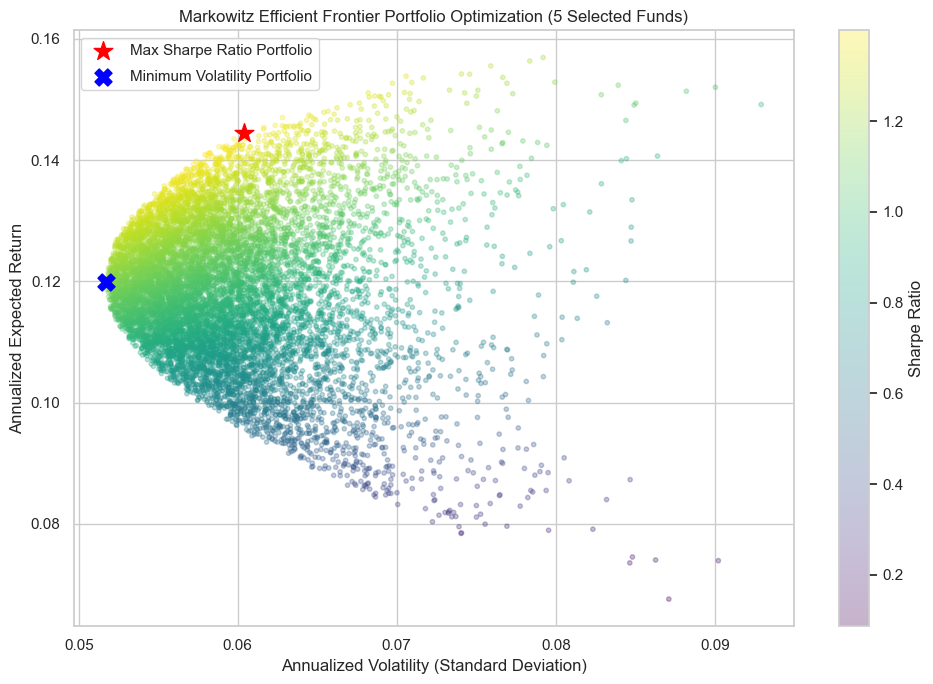

In [10]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_portfolios['volatility'], df_portfolios['return'], c=df_portfolios['sharpe'], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(scatter, label='Sharpe Ratio')

# Mark the maximum Sharpe portfolio
plt.scatter(df_portfolios.loc[max_sharpe_idx, 'volatility'], df_portfolios.loc[max_sharpe_idx, 'return'], color='red', marker='*', s=200, label='Max Sharpe Ratio Portfolio')
# Mark the minimum volatility portfolio
plt.scatter(df_portfolios.loc[min_vol_idx, 'volatility'], df_portfolios.loc[min_vol_idx, 'return'], color='blue', marker='X', s=150, label='Minimum Volatility Portfolio')

plt.title('Markowitz Efficient Frontier Portfolio Optimization (5 Selected Funds)')
plt.xlabel('Annualized Volatility (Standard Deviation)')
plt.ylabel('Annualized Expected Return')
plt.legend(labelspacing=0.8)
plt.tight_layout()
plt.show()

In [11]:
conn.close()